In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from jpype.types import JInt, JArray, JString
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
Permutation = jpype.JClass("utils.permutation_lab_4.Permutation")
GrayCodeMethod = jpype.JClass("utils.permutation_lab_4.Permutation$GrayCodeMethod")
FisherYatesMethod = jpype.JClass("utils.permutation_lab_4.Permutation$FisherYatesMethod")
KnuthMethod = jpype.JClass("utils.permutation_lab_4.Permutation$KnuthMethod")

Тестирование генерации перестановок кодом Грэя:

Тестирование для n = 3
Количество перестановок для n=3: 6
Время выполнения: 0.04 мс
Первые 5 перестановок:
1. [1, 2, 3]
2. [1, 3, 2]
3. [3, 1, 2]
4. [3, 2, 1]
5. [2, 3, 1]

Тестирование для n = 4
Количество перестановок для n=4: 24
Время выполнения: 0.02 мс
Первые 5 перестановок:
1. [1, 2, 3, 4]
2. [1, 2, 4, 3]
3. [1, 4, 2, 3]
4. [4, 1, 2, 3]
5. [4, 1, 3, 2]

Тестирование для n = 5
Количество перестановок для n=5: 120
Время выполнения: 0.04 мс
Первые 5 перестановок:
1. [1, 2, 3, 4, 5]
2. [1, 2, 3, 5, 4]
3. [1, 2, 5, 3, 4]
4. [1, 5, 2, 3, 4]
5. [5, 1, 2, 3, 4]

Тестирование для n = 6
Количество перестановок для n=6: 720
Время выполнения: 0.16 мс
Первые 5 перестановок:
1. [1, 2, 3, 4, 5, 6]
2. [1, 2, 3, 4, 6, 5]
3. [1, 2, 3, 6, 4, 5]
4. [1, 2, 6, 3, 4, 5]
5. [1, 6, 2, 3, 4, 5]

Тестирование для n = 7
Количество перестановок для n=7: 5040
Время выполнения: 1.05 мс
Первые 5 перестановок:
1. [1, 2, 3, 4, 5, 6, 7]
2. [1, 2, 3, 4, 5, 7, 6]
3. [

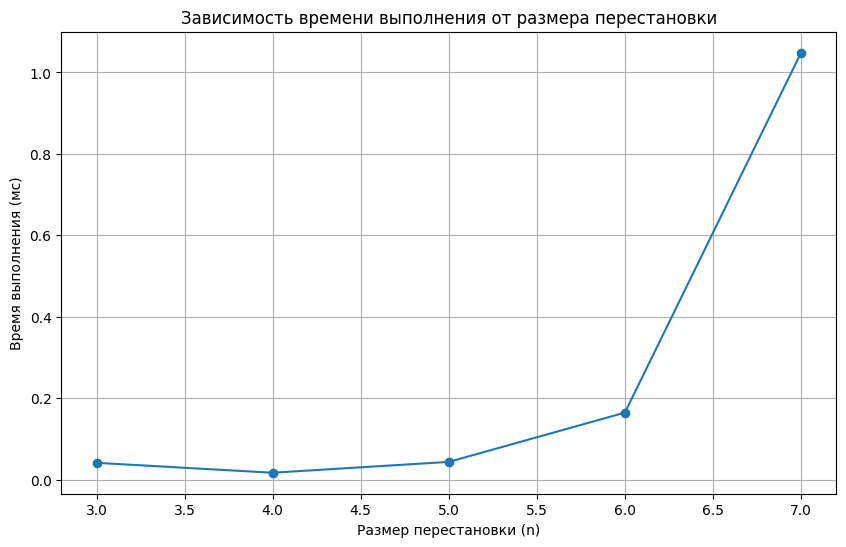


Сравнительный анализ алгоритмов генерации случайных перестановок:

Тестирование для n = 10

Тестирование для n = 100

Тестирование для n = 1000

Тестирование для n = 10000


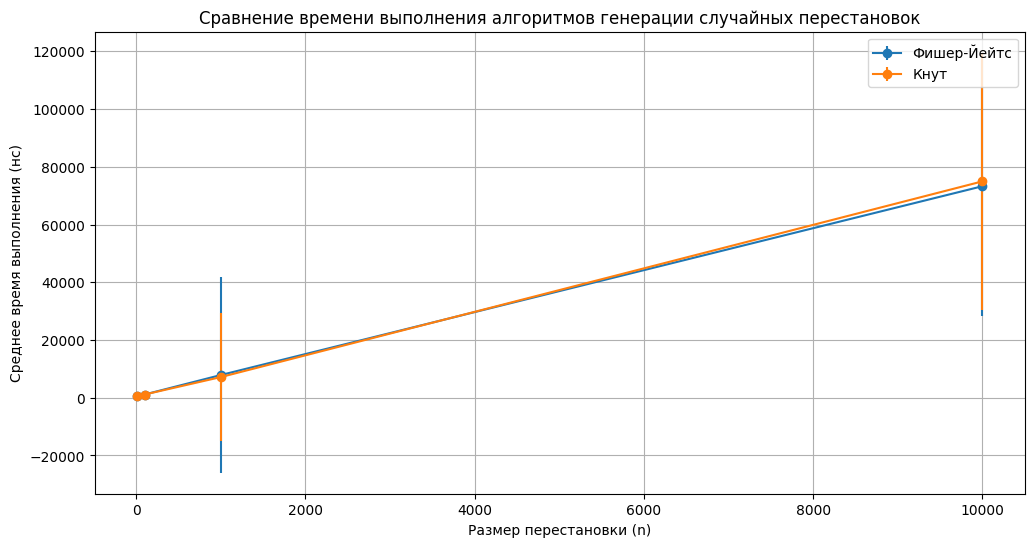


Результаты сравнения методов:
      Фишер-Йейтс (среднее) Фишер-Йейтс (ст. откл.) Кнут (среднее)  \
n                                                                    
10                  0.00 мс                 0.00 мс        0.00 мс   
100                 0.00 мс                 0.00 мс        0.00 мс   
1000                0.01 мс                 0.03 мс        0.01 мс   
10000               0.07 мс                 0.04 мс        0.07 мс   

      Кнут (ст. откл.)  
n                       
10             0.00 мс  
100            0.00 мс  
1000           0.02 мс  
10000          0.04 мс  


In [ ]:
def test_gray_code(n: int):
    gray_code = GrayCodeMethod()
    result = gray_code.generate(n)
    
    print(f"Количество перестановок для n={n}: {len(result.permutations)}")
    print(f"Время выполнения: {result.executionTime / 1e6:.2f} мс")
    
    # Вывод первых 5 перестановок
    print("Первые 5 перестановок:")
    for i in range(min(5, len(result.permutations))):
        print(f"{i+1}. {list(result.permutations[i])}")
    
    return result.executionTime

def test_random_methods(n: int, iterations: int = 1000):
    fisher_yates = FisherYatesMethod()
    knuth = KnuthMethod()
    
    fisher_times = []
    knuth_times = []
    
    for _ in range(iterations):
        # Тестирование метода Фишера-Йейтса
        result = fisher_yates.generate(n)
        fisher_times.append(result.executionTime)
        
        # Тестирование метода Кнута
        result = knuth.generate(n)
        knuth_times.append(result.executionTime)
    
    return {
        'fisher_yates': {
            'mean': np.mean(fisher_times),
            'std': np.std(fisher_times)
        },
        'knuth': {
            'mean': np.mean(knuth_times),
            'std': np.std(knuth_times)
        }
    }

def main():
    print("Тестирование генерации перестановок кодом Грэя:")
    n_values = [3, 4, 5, 6, 7]
    execution_times = []
    
    for n in n_values:
        print(f"\nТестирование для n = {n}")
        time = test_gray_code(n)
        execution_times.append(time)
    
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, [t / 1e6 for t in execution_times], 'o-')
    plt.xlabel('Размер перестановки (n)')
    plt.ylabel('Время выполнения (мс)')
    plt.title('Зависимость времени выполнения от размера перестановки')
    plt.grid(True)
    plt.show()
    
    print("\nСравнительный анализ алгоритмов генерации случайных перестановок:")
    n_values = [10, 100, 1000, 10000]
    results = {}
    
    for n in n_values:
        print(f"\nТестирование для n = {n}")
        results[n] = test_random_methods(n)
    
    # Визуализация результатов случайных методов
    plt.figure(figsize=(12, 6))
    
    fisher_means = [results[n]['fisher_yates']['mean'] for n in n_values]
    fisher_stds = [results[n]['fisher_yates']['std'] for n in n_values]
    knuth_means = [results[n]['knuth']['mean'] for n in n_values]
    knuth_stds = [results[n]['knuth']['std'] for n in n_values]
    
    plt.errorbar(n_values, fisher_means, yerr=fisher_stds, fmt='o-', label='Фишер-Йейтс')
    plt.errorbar(n_values, knuth_means, yerr=knuth_stds, fmt='o-', label='Кнут')
    
    plt.xlabel('Размер перестановки (n)')
    plt.ylabel('Среднее время выполнения (нс)')
    plt.title('Сравнение времени выполнения алгоритмов генерации случайных перестановок')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Вывод результатов в таблицу
    data = []
    for n in n_values:
        data.append({
            'n': n,
            'Фишер-Йейтс (среднее)': f"{results[n]['fisher_yates']['mean'] / 1e6:.2f} мс",
            'Фишер-Йейтс (ст. откл.)': f"{results[n]['fisher_yates']['std'] / 1e6:.2f} мс",
            'Кнут (среднее)': f"{results[n]['knuth']['mean'] / 1e6:.2f} мс",
            'Кнут (ст. откл.)': f"{results[n]['knuth']['std'] / 1e6:.2f} мс"
        })
    
    df = pd.DataFrame(data)
    df.set_index('n', inplace=True)
    print("\nРезультаты сравнения методов:")
    print(df)

if __name__ == "__main__":
    main() 